In [39]:
from headers import functions as fn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from headers import thermal_interpolator as ti
import scienceplots

# plt.style.use(['science','bright'])
plt.style.use(['science', 'std-colors'])
plt.rcParams.update({'figure.dpi': '300'})
mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.style.use(['no-latex'])


In [30]:

# # Grid
# dim = 1
# num_points = [51,101,201,401,801,1601,3201,6401]

# noise_token = 0
# n_scale = 0
# noise_type = 'Gaussian'


# rmse_1st_der_implicit = []
# rmse_2nd_der_implicit = []

# rmse_1st_der_explicit = []
# rmse_2nd_der_explicit = []

# rmse_1st_der_fdm      = []
# rmse_2nd_der_fdm      = []


# # Random Grid

# for n in num_points:
#     np.random.seed(42)
#     print(f"\n---For num_points = {n}")
#     x = np.sort(np.random.rand(n))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n_scale)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )



#     y_implicit, dFdX_implicit, d2FdX2_implicit, theta_optimum,_,_ = ti.derivatives_1D_matrix(training_data, noise_token, scale = scale[0])
#     rmse_1st_der_implicit.append(ti.L2(dFdX_implicit[1:-1]*scale[0],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_implicit.append(ti.L2(d2FdX2_implicit[1:-1]*scale[0],training_data[1:-1,4])/scale[2])



# for n in num_points:
#     np.random.seed(42)
#     print(f"\n---For num_points = {n}")
#     x = np.sort(np.random.rand(n))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)


#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n_scale)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )



#     y_explicit, dFdX_explicit, d2FdX2_explicit, _,_ = ti.derivatives_1D_explicit(training_data, noise_token, scale = scale[0])
#     rmse_1st_der_explicit.append(ti.L2(dFdX_explicit[1:-1]*scale[0],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_explicit.append(ti.L2(d2FdX2_explicit[1:-1]*scale[0],training_data[1:-1,4])/scale[2])



# for n in num_points:
#     np.random.seed(42)
#     print(f"\n---For num_points = {n}")
#     x = np.sort(np.random.rand(n))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n_scale)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

#     x = training_data[:, 0]
#     y = training_data[:, 1+noise_token]  
#     # Initialize derivative arrays
#     dFdX_fdm = np.zeros_like(y)
#     d2FdX2_fdm = np.zeros_like(y)

#     # First derivative using non-uniform central difference
#     for i in range(1, len(x) - 1):
#         x0, x1, x2 = x[i - 1], x[i], x[i + 1]
#         y0, y1, y2 = y[i - 1], y[i], y[i + 1]
        
#         h0 = x1 - x0
#         h1 = x2 - x1
#         denom = h0 * h1 * (h0 + h1)
        
#         dFdX_fdm[i] = (h1**2 * (y1 - y0) + h0**2 * (y2 - y1)) / denom

#     # Forward difference at the first point
#     dFdX_fdm[0] = (y[1] - y[0]) / (x[1] - x[0])

#     # Backward difference at the last point
#     dFdX_fdm[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])

#     # Second derivative using non-uniform central difference
#     for i in range(1, len(x) - 1):
#         x0, x1, x2 = x[i - 1], x[i], x[i + 1]
#         y0, y1, y2 = y[i - 1], y[i], y[i + 1]
        
#         h0 = x1 - x0
#         h1 = x2 - x1
        
#         d2FdX2_fdm[i] = 2 * (h1 * (y0 - y1) + h0 * (y2 - y1)) / (h0 * h1 * (h0 + h1))

#     # Set boundaries to NaN
#     d2FdX2_fdm[0] = np.nan
#     d2FdX2_fdm[-1] = np.nan


#     rmse_1st_der_fdm.append(ti.L2(dFdX_fdm[1:-1],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_fdm.append(ti.L2(d2FdX2_fdm[1:-1],training_data[1:-1,4])/scale[2])




---For num_points = 51

running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 5.6649909147377525e-05, with test rmse 0.0003991611837089433, index is 8
Complete!

---For num_points = 101

running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 2.475973712681723e-05, with test rmse 0.00010767705496656985, index is 7
Complete!

---For num_points = 201

running implicit


...

Selected theta is 3.345589061648668e-07, with test rmse 7.908905089281026e-08, index is 5
-------------------------------------
Complete!

---For num_points = 3201

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 8.455555803734983e-08, with test rmse 7.636553707379527e-09, index is 5
-------------------------------------
Complete!

---For num_points = 6401

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 4.2401539225117713e-08, with test rmse 1.184066848828357e-09, index is 4
-------------------------------------
Complete!

---For num_points = 51

---For num_points = 101

---For num_points = 201

---For num_points = 401

---For num_points = 801

---For num_points = 1601

---For num_points = 3201

---For num_points = 6401


In [31]:

# from scipy.interpolate import UnivariateSpline


# # Grid
# dim = 1
# num_points_noisy = 401

# noise_token = 1
# n_scale = [0.01,0.05,0.1,0.15]
# noise_type = 'Gaussian'


# rmse_1st_der_implicit_noisy = []
# rmse_2nd_der_implicit_noisy = []

# rmse_1st_der_explicit_noisy = []
# rmse_2nd_der_explicit_noisy = []

# rmse_1st_der_fdm_noisy      = []
# rmse_2nd_der_fdm_noisy      = []

# rmse_1st_der_spline_noisy      = []
# rmse_2nd_der_spline_noisy      = []


# # Random Grid

# for n in n_scale:
#     np.random.seed(42)
#     # print(f"\n---For noise = {n}")
#     x = np.sort(np.random.rand(num_points_noisy))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )



#     y_implicit, dFdX_implicit, d2FdX2_implicit, theta_optimum,_,_ = ti.derivatives_1D_matrix(training_data, noise_token, scale = scale[0])
#     rmse_1st_der_implicit_noisy.append(ti.L2(dFdX_implicit[1:-1]*scale[0],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_implicit_noisy.append(ti.L2(d2FdX2_implicit[1:-1]*scale[0],training_data[1:-1,4])/scale[2])



# for n in n_scale:
#     np.random.seed(42)
#     # print(f"\n---For noise = {n}")
#     x = np.sort(np.random.rand(num_points_noisy))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )



#     y_explicit, dFdX_explicit, d2FdX2_explicit, _,_ = ti.derivatives_1D_explicit(training_data, noise_token, scale = scale[0])
#     rmse_1st_der_explicit_noisy.append(ti.L2(dFdX_explicit[1:-1]*scale[0],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_explicit_noisy.append(ti.L2(d2FdX2_explicit[1:-1]*scale[0],training_data[1:-1,4])/scale[2])



# for n in n_scale:
#     np.random.seed(42)
#     # print(f"\n---For noise = {n}")
#     x = np.sort(np.random.rand(num_points_noisy))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

#     x = training_data[:, 0]
#     y = training_data[:, 1+noise_token]  
#     # Initialize derivative arrays
#     dFdX_fdm = np.zeros_like(y)
#     d2FdX2_fdm = np.zeros_like(y)

#     # First derivative using non-uniform central difference
#     for i in range(1, len(x) - 1):
#         x0, x1, x2 = x[i - 1], x[i], x[i + 1]
#         y0, y1, y2 = y[i - 1], y[i], y[i + 1]
        
#         h0 = x1 - x0
#         h1 = x2 - x1
#         denom = h0 * h1 * (h0 + h1)
        
#         dFdX_fdm[i] = (h1**2 * (y1 - y0) + h0**2 * (y2 - y1)) / denom

#     # Forward difference at the first point
#     dFdX_fdm[0] = (y[1] - y[0]) / (x[1] - x[0])

#     # Backward difference at the last point
#     dFdX_fdm[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])

#     # Second derivative using non-uniform central difference
#     for i in range(1, len(x) - 1):
#         x0, x1, x2 = x[i - 1], x[i], x[i + 1]
#         y0, y1, y2 = y[i - 1], y[i], y[i + 1]
        
#         h0 = x1 - x0
#         h1 = x2 - x1
        
#         d2FdX2_fdm[i] = 2 * (h1 * (y0 - y1) + h0 * (y2 - y1)) / (h0 * h1 * (h0 + h1))

#     # Set boundaries to NaN
#     d2FdX2_fdm[0] = np.nan
#     d2FdX2_fdm[-1] = np.nan


#     rmse_1st_der_fdm_noisy.append(ti.L2(dFdX_fdm[1:-1],training_data[1:-1,3])/scale[1])
#     rmse_2nd_der_fdm_noisy.append(ti.L2(d2FdX2_fdm[1:-1],training_data[1:-1,4])/scale[2])
# for n in n_scale:
#     np.random.seed(42)
#     # print(f"\n---For noise = {n}")
#     x = np.sort(np.random.rand(num_points_noisy))  


#     F = np.zeros_like(x)
#     dFdX = np.zeros_like(x)
#     d2FdX2 = np.zeros_like(x)
#     F, dFdX, d2FdX2 = fn.Camel1D(x)



#     # Normalize
#     scale = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])



#     F = fn.Normalize(F,scale[0])

#     dFdX = fn.Normalize(dFdX,scale[0])
#     d2FdX2 = fn.Normalize(d2FdX2,scale[0])
#     # Add Noise
#     Fn = fn.AddNoise(F,noise_type,n)

#     training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

#     x = training_data[:, 0]
#     y = training_data[:, 1+noise_token]  

#     # s = smoothing factor — larger = more smoothing
#     # You can make it depend on noise level, e.g. s = 0.5 * n * len(x)
#     sigma = n / 3.0
#     window = len(x) * (sigma ** 2)
#     spline = UnivariateSpline(x, y, s=window, k=3)   # k=3 , cubic spline

#     dFdX_spline   = spline.derivative(n=1)(x)
#     d2FdX2_spline = spline.derivative(n=2)(x)

#     # RMSE
#     rmse_1st_der_spline_noisy.append( ti.L2(dFdX_spline[1:-1],   training_data[1:-1,3]) / scale[1] )
#     rmse_2nd_der_spline_noisy.append( ti.L2(d2FdX2_spline[1:-1], training_data[1:-1,4]) / scale[2] )





running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 0.00017447737470504854, with test rmse 0.0038116871467055607, index is 0
Complete!

running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 0.00017447737470504854, with test rmse 0.019014235959301413, index is 0
Complete!

running implicit


...

Selected theta is 0.00017447737470504854, with test rmse 0.019014235959301413, index is 0
-------------------------------------
Complete!

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 0.00017447737470504854, with test rmse 0.03802642912514036, index is 0
-------------------------------------
Complete!

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 0.00017447737470504854, with test rmse 0.05703929045005522, index is 0
-------------------------------------
Complete!


In [32]:

# # ───────────────────────────────────────────────
# # 1. Non-noisy (convergence with N) data
# # ───────────────────────────────────────────────

# data_clean = pd.DataFrame({
#     'N': num_points,
#     'RMSE_1st_FD':      rmse_1st_der_fdm,
#     'RMSE_1st_Explicit': rmse_1st_der_explicit,
#     'RMSE_1st_Implicit': rmse_1st_der_implicit,
#     'RMSE_2nd_FD':      rmse_2nd_der_fdm,
#     'RMSE_2nd_Explicit': rmse_2nd_der_explicit,
#     'RMSE_2nd_Implicit': rmse_2nd_der_implicit,
# })

# # Save
# data_clean.to_csv('convergence_non_noisy.csv', index=False, float_format='%.6e')
# print("Saved convergence_non_noisy.csv")
# print(data_clean)


# # ───────────────────────────────────────────────
# # 2. Noisy data (RMSE vs noise level)
# # ───────────────────────────────────────────────

# data_noisy = pd.DataFrame({
#     'noise_level': n_scale,
#     'RMSE_1st_FD':      rmse_1st_der_fdm_noisy,
#     'RMSE_1st_spline' : rmse_1st_der_spline_noisy,
#     'RMSE_1st_Explicit': rmse_1st_der_explicit_noisy,
#     'RMSE_1st_Implicit': rmse_1st_der_implicit_noisy,
#     'RMSE_2nd_FD':      rmse_2nd_der_fdm_noisy,
#     'RMSE_2nd_spline' : rmse_2nd_der_spline_noisy,
#     'RMSE_2nd_Explicit': rmse_2nd_der_explicit_noisy,
#     'RMSE_2nd_Implicit': rmse_2nd_der_implicit_noisy,
# })

# data_noisy.to_csv('convergence_noisy.csv', index=False, float_format='%.6e')
# print("\nSaved convergence_noisy.csv")
# print(data_noisy)

Saved convergence_non_noisy.csv
      N   RMSE_1st_FD  RMSE_1st_Explicit  RMSE_1st_Implicit  RMSE_2nd_FD  \
0    51  4.215507e-03           0.009146           0.009150     0.044937   
1   101  1.395734e-03           0.002506           0.002504     0.024197   
2   201  3.700816e-04           0.001054           0.001074     0.013584   
3   401  8.507023e-05           0.000188           0.000204     0.006491   
4   801  2.460161e-05           0.000045           0.000051     0.002780   
5  1601  5.261855e-06           0.000015           0.000016     0.001474   
6  3201  1.422022e-06           0.000004           0.000004     0.000766   
7  6401  3.740702e-07           0.000002           0.000002     0.000377   

   RMSE_2nd_Explicit  RMSE_2nd_Implicit  
0           0.069746           0.080188  
1           0.046468           0.048496  
2           0.024516           0.027906  
3           0.011176           0.011825  
4           0.004761           0.004993  
5           0.002579           

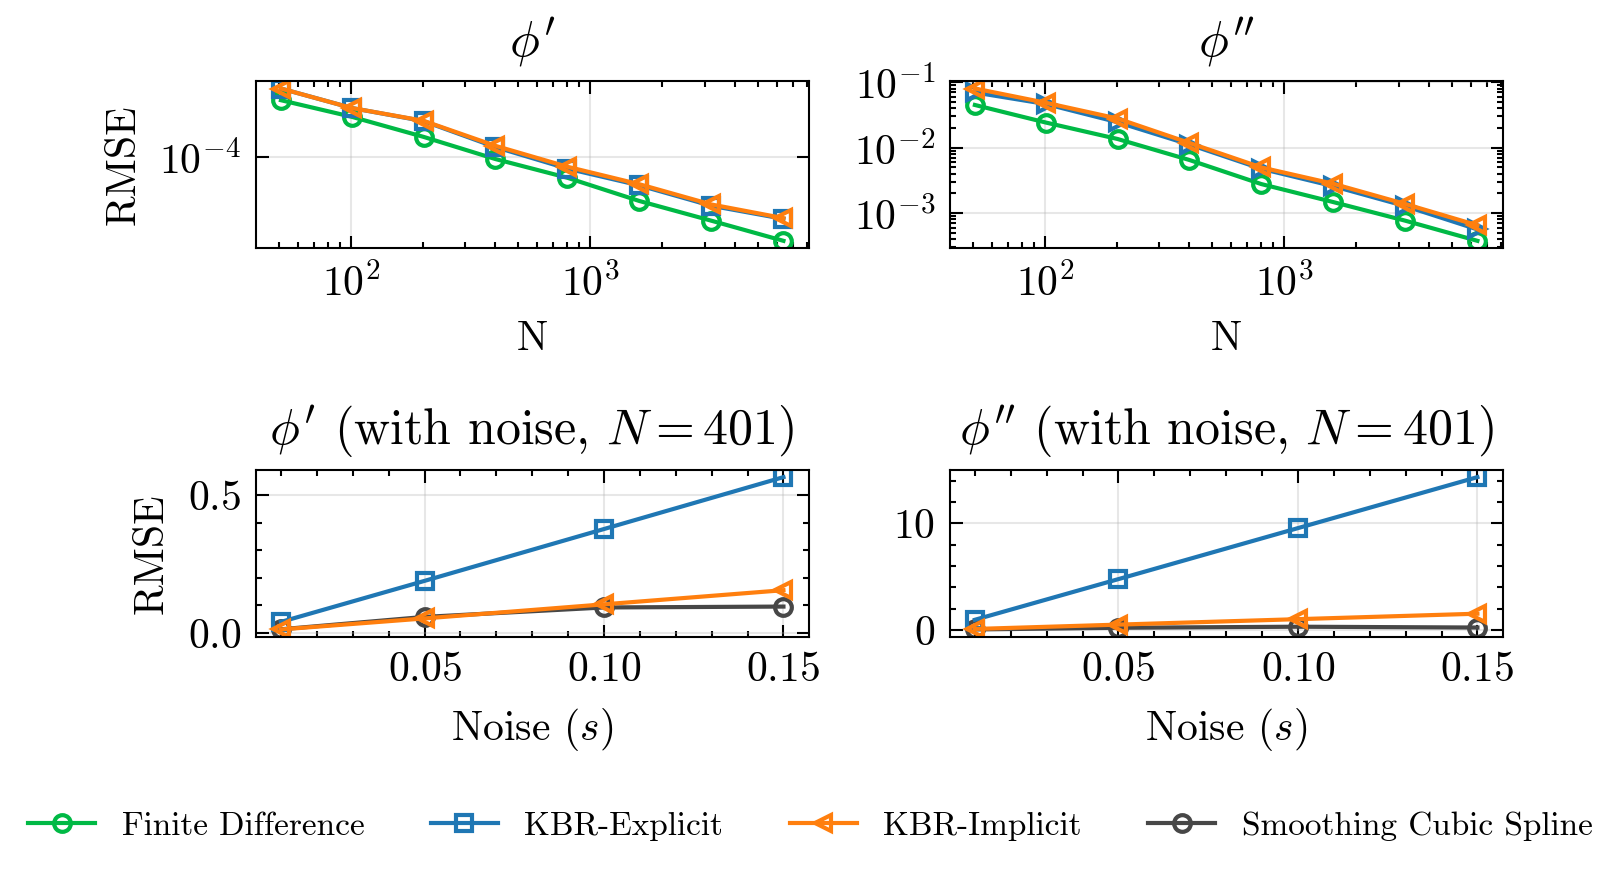

Order of convergence (FD, dF/dx)        : 1.96
Order of convergence (Explicit, dF/dx)  : 1.85
Order of convergence (Implicit, dF/dx)  : 1.83

Order of convergence (FD, d2F/dx2)      : 1.00
Order of convergence (Explicit, d2F/dx2): 1.02
Order of convergence (Implicit, d2F/dx2): 1.02


In [49]:

df_clean = pd.read_csv('./datafiles/convergence_non_noisy.csv')
df_noisy = pd.read_csv('./datafiles/convergence_noisy.csv')
num_points_noisy = 401
N = df_clean['N'].values
noise_levels = df_noisy['noise_level'].values
# Extract arrays
num_points = df_clean['N'].values.astype(int)

# Clean data
rmse_1st_der_fdm       = df_clean['RMSE_1st_FD'].values
rmse_1st_der_explicit  = df_clean['RMSE_1st_Explicit'].values
rmse_1st_der_implicit  = df_clean['RMSE_1st_Implicit'].values
rmse_2nd_der_fdm       = df_clean['RMSE_2nd_FD'].values
rmse_2nd_der_explicit  = df_clean['RMSE_2nd_Explicit'].values
rmse_2nd_der_implicit  = df_clean['RMSE_2nd_Implicit'].values

# Noisy data
rmse_1st_der_fdm_noisy       = df_noisy['RMSE_1st_FD'].values
rmse_1st_der_explicit_noisy  = df_noisy['RMSE_1st_Explicit'].values
rmse_1st_der_implicit_noisy  = df_noisy['RMSE_1st_Implicit'].values
rmse_1st_der_spline_noisy    = df_noisy['RMSE_1st_spline'].values

rmse_2nd_der_fdm_noisy       = df_noisy['RMSE_2nd_FD'].values
rmse_2nd_der_explicit_noisy  = df_noisy['RMSE_2nd_Explicit'].values
rmse_2nd_der_implicit_noisy  = df_noisy['RMSE_2nd_Implicit'].values
rmse_2nd_der_spline_noisy    = df_noisy['RMSE_2nd_spline'].values
# ==============================
# Figure setup
# ==============================
fig, axs = plt.subplots(2, 2, figsize=(5, 3), sharex=False, sharey=False)
COL_FD        = mcolors[1] 
COL_EXPLICIT = 'tab:blue'
COL_IMPLICIT = 'tab:orange'
COL_SPLINE    = mcolors[5]  


# ---------- First derivative subplot (clean data) ----------
ax = axs[0,0]
ax.loglog(num_points, rmse_1st_der_fdm, 'o-', color=COL_FD, ms=4, mfc='none', label='Finite Difference')
ax.loglog(num_points, rmse_1st_der_explicit, 's-', color=COL_EXPLICIT, ms=4, mfc='none', label='KBR-Explicit')
ax.loglog(num_points, rmse_1st_der_implicit, '<-', color=COL_IMPLICIT, ms=4, mfc='none', label='KBR-Implicit')
ax.plot(np.nan, np.nan, 'o-', color=COL_SPLINE, ms=4, mfc='none', label='Smoothing Cubic Spline')

ax.set_xlabel('N')
ax.set_ylabel('RMSE')
ax.set_title(r"$\phi'$")
ax.grid(alpha=0.3)

# ---------- Second derivative subplot (clean data) ----------
ax = axs[0,1]
ax.loglog(num_points, rmse_2nd_der_fdm, 'o-', color=COL_FD, ms=4, mfc='none', label='Finite Difference')
ax.loglog(num_points, rmse_2nd_der_explicit, '>-', color=COL_EXPLICIT, ms=4, mfc='none', label='Present (Explicit)')
ax.loglog(num_points, rmse_2nd_der_implicit, '<-', color=COL_IMPLICIT, ms=4, mfc='none', label='Present (Implicit)')

ax.set_xlabel('N')
ax.set_title(r"$\phi''$")
ax.grid(alpha=0.3)

# ---------- First derivative subplot (noisy data) ----------
ax = axs[1,0]
ax.plot(noise_levels, rmse_1st_der_spline_noisy, 'o-', color=COL_SPLINE, ms=4, mfc='none', label='Smoothing Cubic Spline')
ax.plot(noise_levels, rmse_1st_der_explicit_noisy, 's-', color=COL_EXPLICIT, ms=4, mfc='none', label='Present (Explicit)')
ax.plot(noise_levels, rmse_1st_der_implicit_noisy, '<-', color=COL_IMPLICIT, ms=4, mfc='none', label='Present (Implicit)')

ax.set_xlabel(r'Noise $(s)$')
ax.set_ylabel('RMSE')
ax.set_title(rf"$\phi'$ (with noise, $N=${num_points_noisy})")
ax.grid(alpha=0.3)

# ---------- Second derivative subplot (noisy data) ----------
ax = axs[1,1]
ax.plot(noise_levels, rmse_2nd_der_spline_noisy, 'o-', color=COL_SPLINE, ms=4, mfc='none', label='Smoothing Cubic Spline')
ax.plot(noise_levels, rmse_2nd_der_explicit_noisy, 's-', color=COL_EXPLICIT, ms=4, mfc='none', label='Present (Explicit)')
ax.plot(noise_levels, rmse_2nd_der_implicit_noisy, '<-', color=COL_IMPLICIT, ms=4, mfc='none', label='Present (Implicit)')

ax.set_xlabel(r'Noise $(s)$')
# ax.set_ylabel('RMSE')
ax.set_title(rf"$\phi''$ (with noise, $N=${num_points_noisy})")
ax.grid(alpha=0.3)

# Compute slopes (first derivative - refinement study)
log_N = np.log(num_points)
slope_fd_1,       _ = np.polyfit(log_N, np.log(rmse_1st_der_fdm),       1)
slope_explicit_1, _ = np.polyfit(log_N, np.log(rmse_1st_der_explicit), 1)
slope_implicit_1, _ = np.polyfit(log_N, np.log(rmse_1st_der_implicit), 1)

# Compute slopes (second derivative - refinement study)
slope_fd_2,       _ = np.polyfit(log_N, np.log(rmse_2nd_der_fdm),       1)
slope_explicit_2, _ = np.polyfit(log_N, np.log(rmse_2nd_der_explicit), 1)
slope_implicit_2, _ = np.polyfit(log_N, np.log(rmse_2nd_der_implicit), 1)

# Legend (take handles from any axes that has all three methods plotted)
handles, labels = axs[0,0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.001)
)

# ==============================
# Layout & Save
# ==============================
plt.tight_layout(rect=[0, 0.08, 1, 1])   # give more bottom space for legend
plt.savefig('./figures/1dcamel_convergence_combined.pdf', bbox_inches='tight')
plt.show()

# Print convergence orders
print(f"Order of convergence (FD, dF/dx)        : {-slope_fd_1:.2f}")
print(f"Order of convergence (Explicit, dF/dx)  : {-slope_explicit_1:.2f}")
print(f"Order of convergence (Implicit, dF/dx)  : {-slope_implicit_1:.2f}")
print()
print(f"Order of convergence (FD, d2F/dx2)      : {-slope_fd_2:.2f}")
print(f"Order of convergence (Explicit, d2F/dx2): {-slope_explicit_2:.2f}")
print(f"Order of convergence (Implicit, d2F/dx2): {-slope_implicit_2:.2f}")